<a href="https://colab.research.google.com/github/anselmo-torres/TP2---LAB---Python/blob/main/Ejercicio_4_TPLAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Ejercicio de programación 4: Acciones argentinas

El objetivo de este ejercicio es analizar datos de 10 acciones argentinas utilizando las librerías yfinance, pandas y matplotlib. Las acciones seleccioandas son Banco Galicia, Banco Macro, Banco BBVA, Banco Supervielle, YPF, Pampa Energía, Transportadora de Gas del Sur, Central Puerto, Edenor y Loma Negra. Tomaremos datos desde el 19 de diciembre del 2020 hasta el 19 de diciembre de 2025.
Comenzamos descargando las series de precios, donde es imoprtante notar que están todos expresados en dólares estadounidenses.

In [17]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Definición de tickers (ADRs argentinos)
tickers = ["GGAL", "BMA", "BBAR", "SUPV", "YPF", "PAM", "TGS", "CEPU", "EDN", "LOMA"]

# Definición de fechas para los últimos 5 años
start_date = "2020-12-19"
end_date = "2025-12-19"

# Descarga de datos
data = yf.download(tickers, start=start_date, end=end_date, group_by='ticker')

# Limpiamos para quedarnos solo con el Precio de Cierre

precios = pd.DataFrame()
for ticker in tickers:
    precios[ticker] = data[ticker]['Close']

# Veamos las primeras files para verificar lo que tenemos
print(precios.head())

/tmp/ipython-input-582994892.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date, group_by='ticker')
[*********************100%***********************]  10 of 10 completed


Datos descargados exitosamente:
                GGAL        BMA      BBAR      SUPV   YPF    PAM   TGS  \
Date                                                                     
2020-12-21  6.683802  11.523120  2.275772  1.794619  5.19  13.72  5.53   
2020-12-22  6.668018  11.418707  2.319819  1.850994  5.01  13.61  5.45   
2020-12-23  6.857408  11.866206  2.327161  1.926161  5.04  13.38  5.45   
2020-12-24  6.849516  11.612625  2.305137  1.883880  4.94  13.28  5.26   
2020-12-28  6.841626  11.560413  2.319819  1.850994  4.91  13.19  5.34   

                CEPU   EDN      LOMA  
Date                                  
2020-12-21  2.262960  3.62  4.197388  
2020-12-22  2.254547  3.61  4.141884  
2020-12-23  2.237722  3.60  4.343082  
2020-12-24  2.220897  3.56  4.259828  
2020-12-28  2.212485  3.81  4.315331  


Continuamos ahora analizando los primeros cuatro años de los datos para graficar las series de precios en simultáneo y los retonos de cada activo. Primero graficamos todas las series de precios juntas. Luego, nos interesa graficar las series de las empresas pertenecientes al sector bancario. Queremos ver si se mueven juntas.

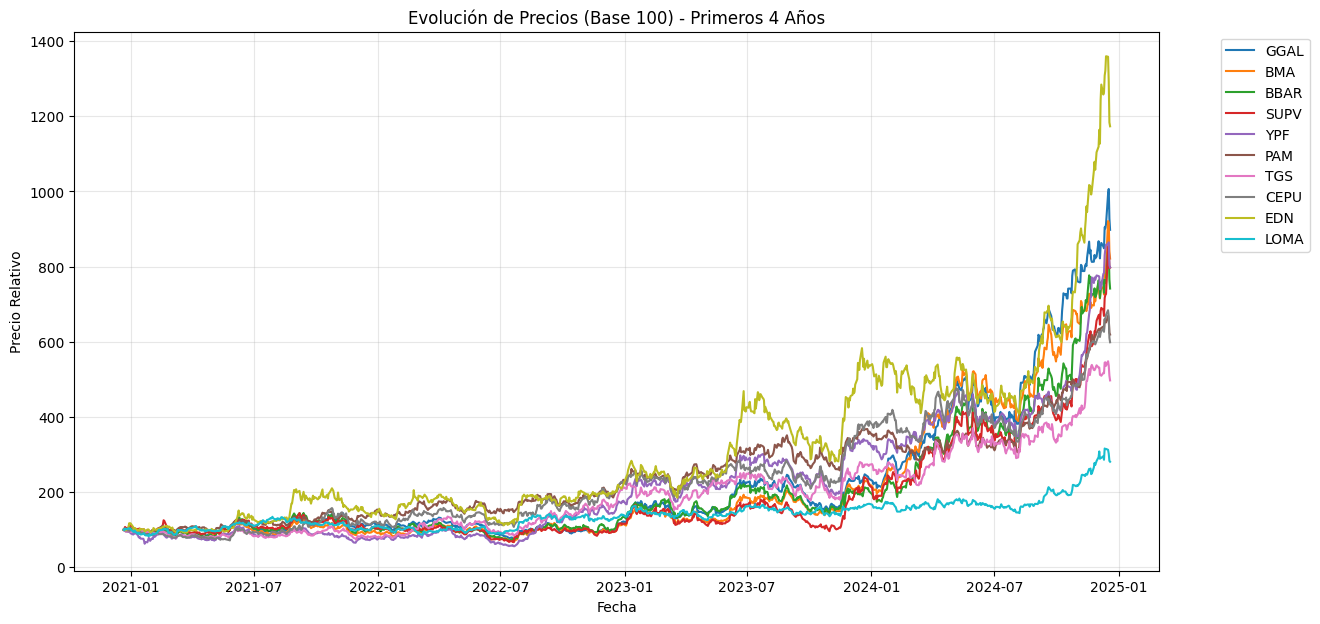

In [18]:
# 1. Definimos el punto de corte para el último año
fecha_corte = "2024-12-19"

# 2. Filtramos los datos de los primeros 4 años
precios_4y = precios.loc[:fecha_corte]

# 3. Graficamos series de precios simultáneas (Normalizadas a 100 para comparar)
# Esto es necesario porque una acción puede valer $10 y otra $1000
plt.figure(figsize=(14, 7))
precios_normalizados = (precios_4y / precios_4y.iloc[0]) * 100
for ticker in tickers:
    plt.plot(precios_normalizados.index, precios_normalizados[ticker], label=ticker)

plt.title("Evolución de Precios (Base 100) - Primeros 4 Años")
plt.xlabel("Fecha")
plt.ylabel("Precio Relativo")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()



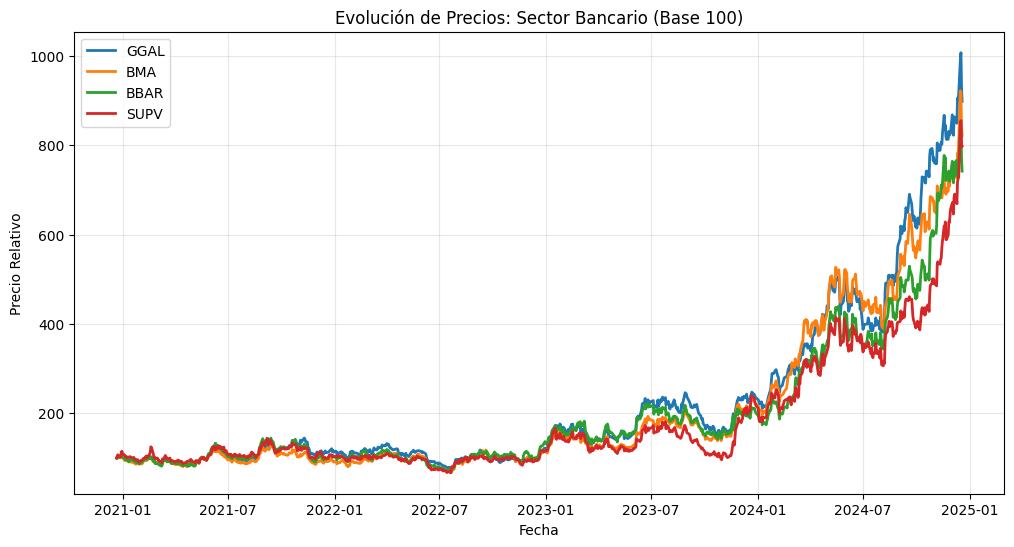

In [21]:
# 1. Definimos el subgrupo de Bancos
bancos = ["GGAL", "BMA", "BBAR", "SUPV"]

# --- GRÁFICO 1: Precios del Sector Bancario ---
plt.figure(figsize=(12, 6))

#Normalizamos nuevamente los datos
datos_bancos = precios_4y[bancos]
datos_bancos_norm = (datos_bancos / datos_bancos.iloc[0]) * 100

for ticker in bancos:
    plt.plot(datos_bancos_norm.index, datos_bancos_norm[ticker], label=ticker, linewidth=2)

plt.title("Evolución de Precios: Sector Bancario (Base 100)")
plt.xlabel("Fecha")
plt.ylabel("Precio Relativo")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



Calculemos ahora los retornos diarios de cada activo y grafiquemos




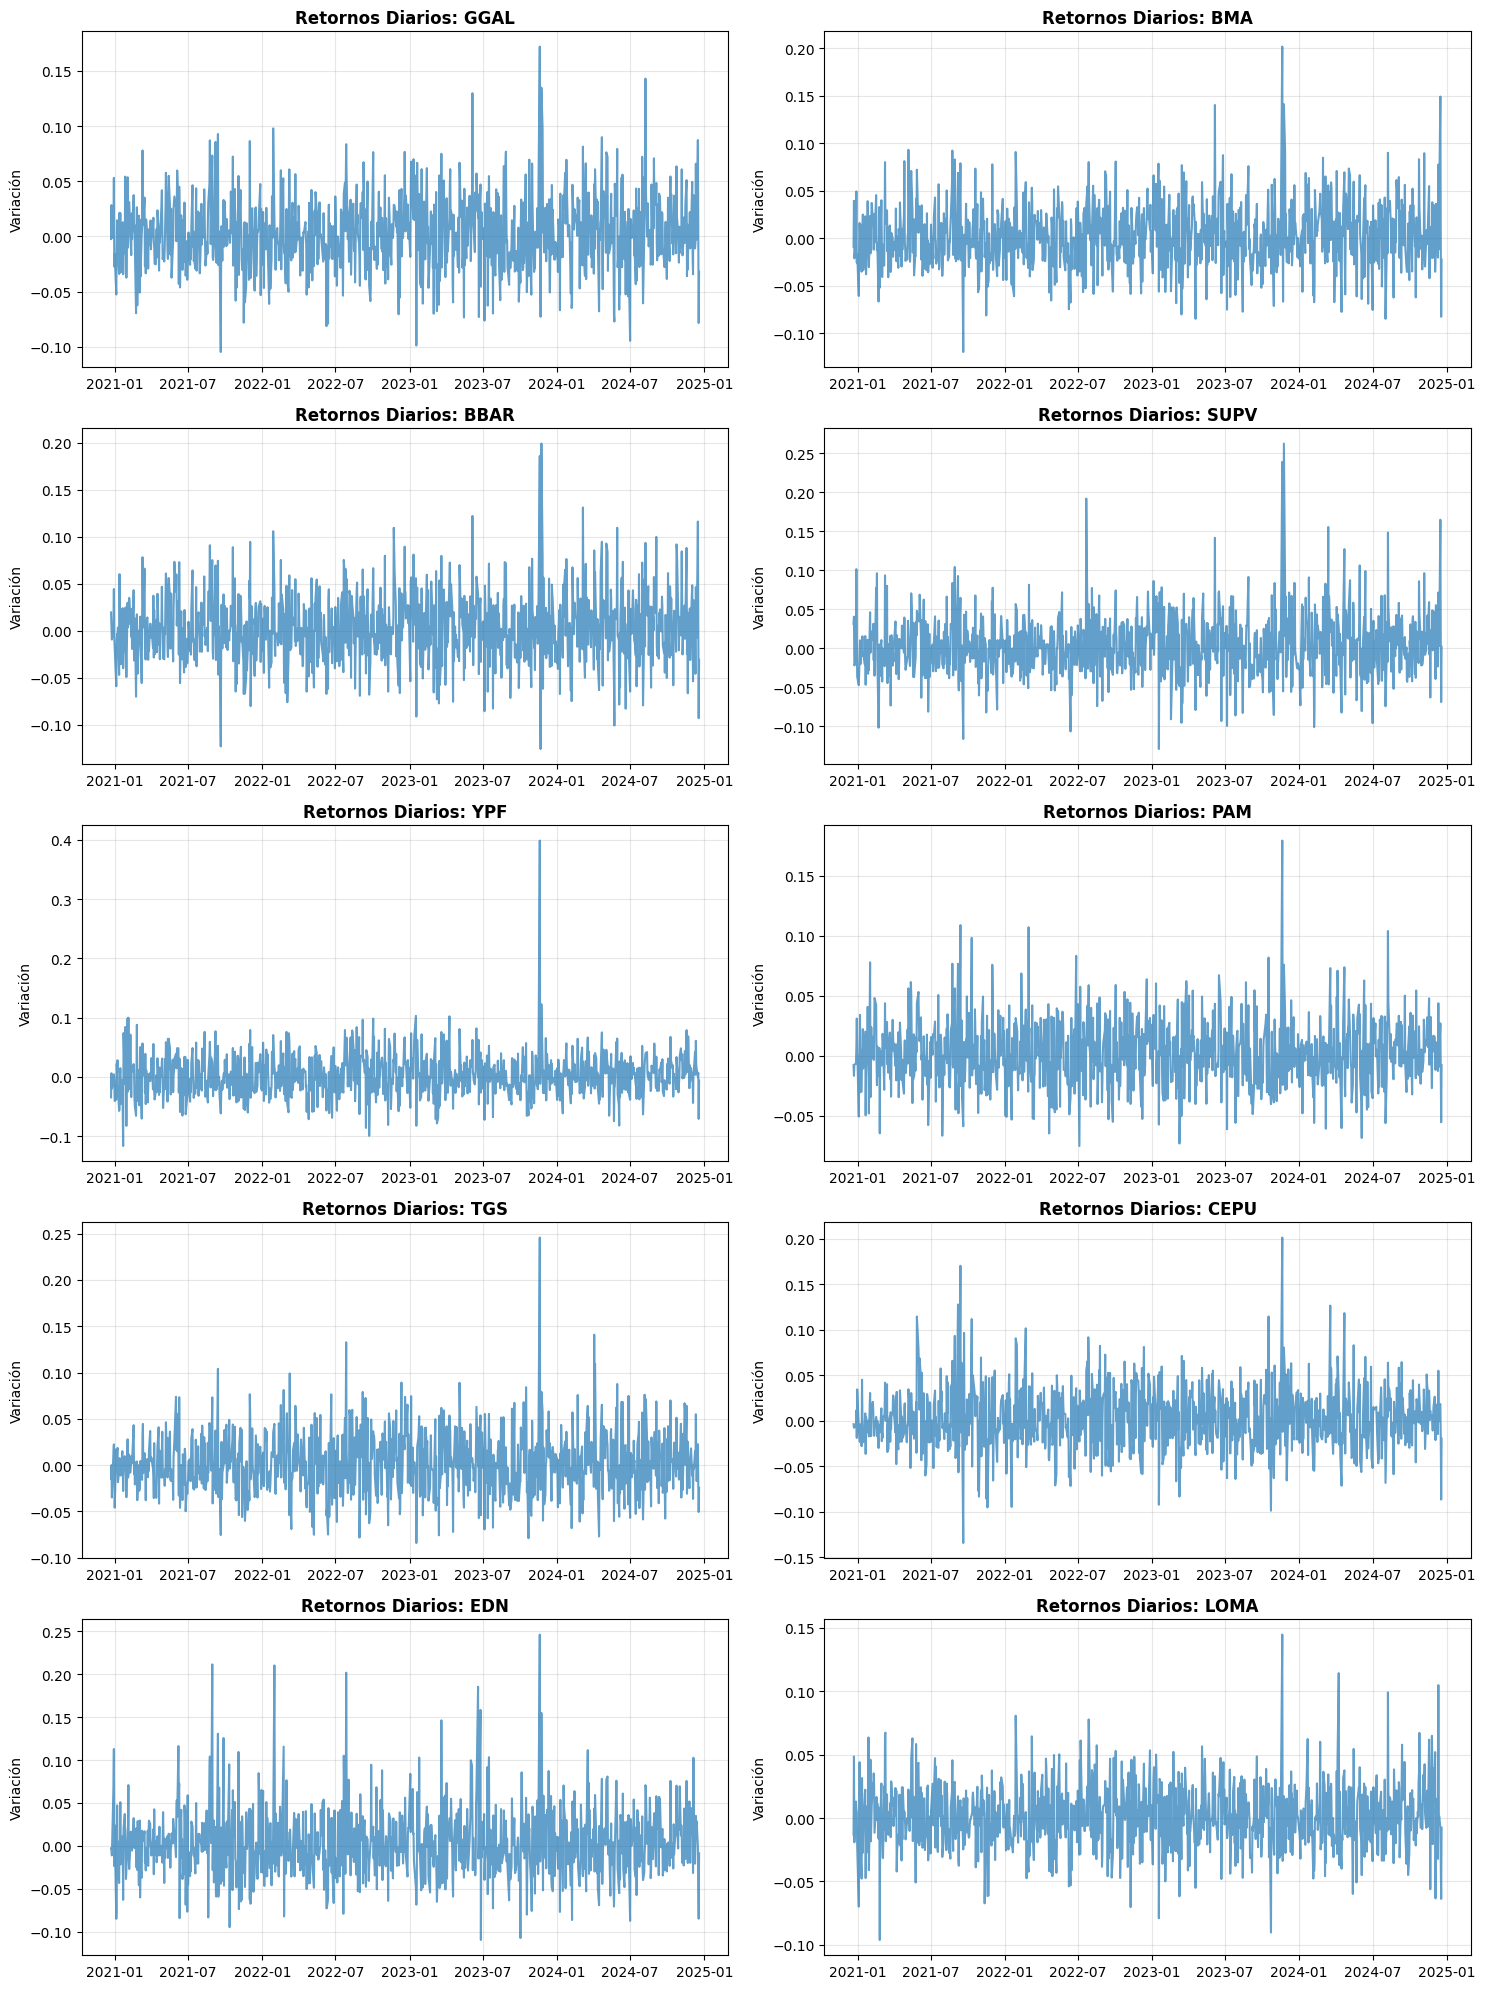

In [22]:
# 1. Calculamos los retornos diarios
# La función pct_change() calcula (Precio_t - Precio_t-1) / Precio_t-1
retornos_4y = precios_4y.pct_change().dropna()

# 2. Configuración de la grilla de gráficos
# Creamos 10 subgráficos (5 filas x 2 columnas) para ver cada activo con claridad
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 20))
axes = axes.flatten() # "Aplanamos" la matriz de ejes para poder iterar sobre ella fácilmente

# 3. Generación de los gráficos
mis_tickers = retornos_4y.columns # Usamos las columnas del dataframe

for i, ticker in enumerate(mis_tickers):
    # Verificamos no pasarnos del número de gráficos disponibles
    if i < len(axes):
        ax = axes[i]
        # Graficamos los retornos en azul con un poco de transparencia
        ax.plot(retornos_4y.index, retornos_4y[ticker], color='tab:blue', alpha=0.7)

        # Detalles estéticos
        ax.set_title(f"Retornos Diarios: {ticker}", fontsize=12, fontweight='bold')
        ax.set_ylabel("Variación")
        ax.grid(True, alpha=0.3)

# Ajustamos el espaciado para que no se superpongan los títulos
plt.tight_layout()
plt.show()

Lo que haremos ahora será graficar los correlogramas de precios y retornos para cada activo. A su vez, graficamos con una sombra gris el intervalo de confianza de 95% para la H0: $\rho_k = 0$. Es decir, para todo valor de la función de autocorrelación que caiga dentro de la sombra, no podemos rechazar la hipótesis nula de que la correlación en cuestión sea 0 para la cantidad de rezagos considerada. La teoría económica nos indica que debemos ver fuerte correlación entre precios (no cambian mucho de un día a otros, los precios son martingalas, etc.) y poca correlación entre retornos (retornos pasados no garantizan retornos futuros).

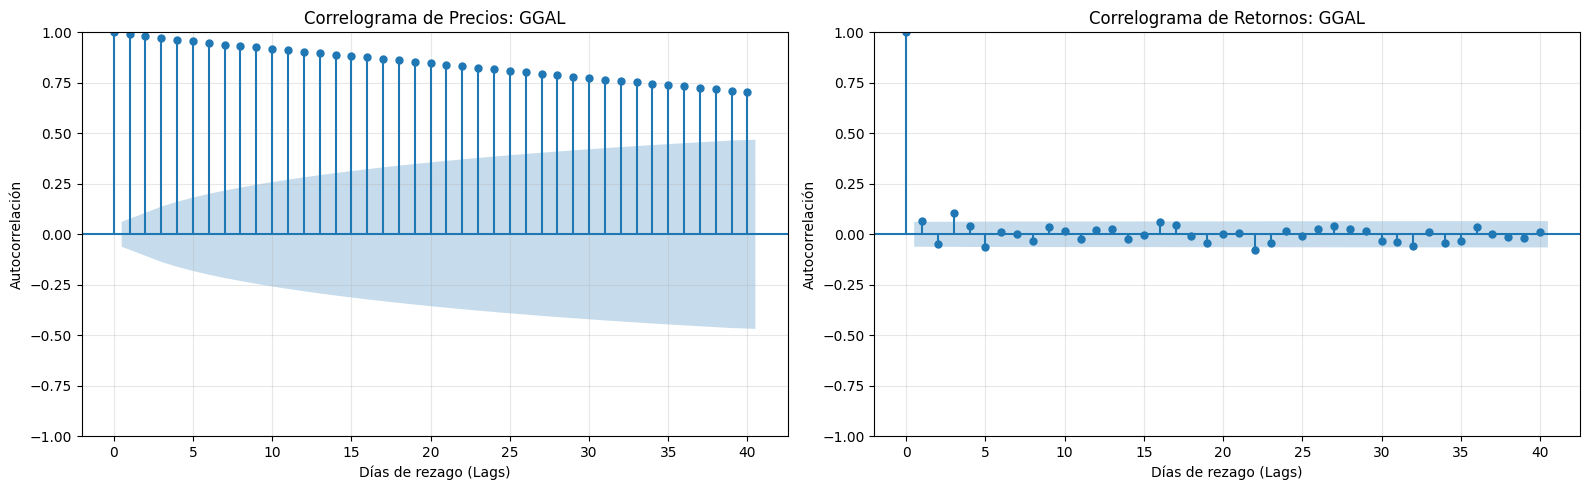

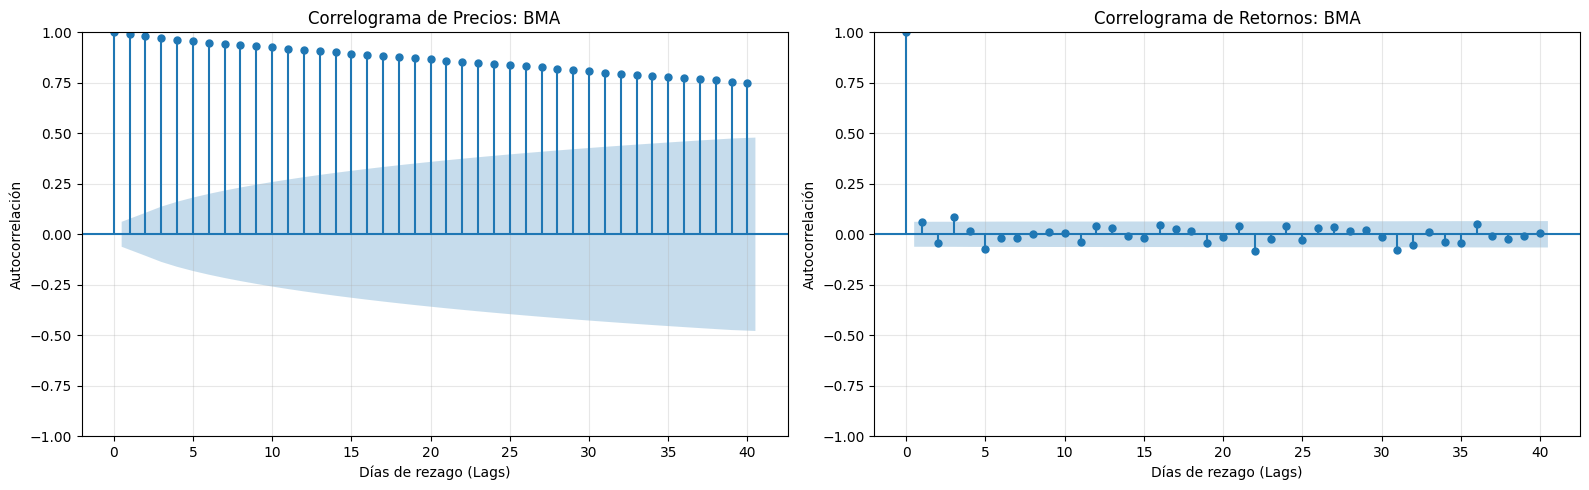

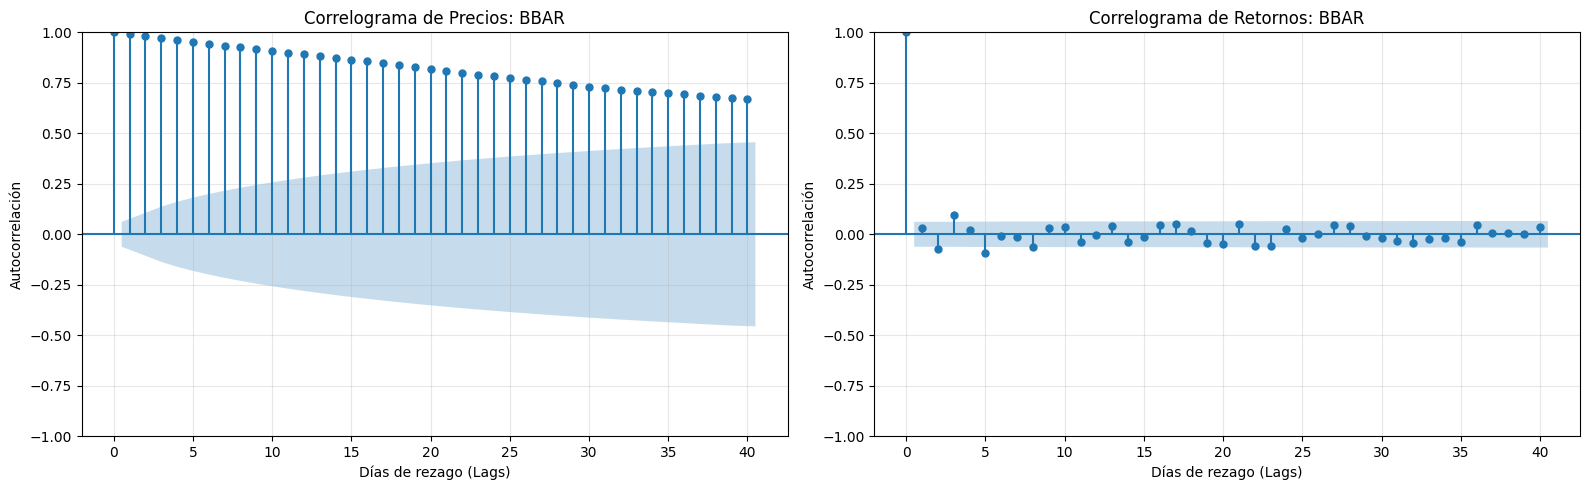

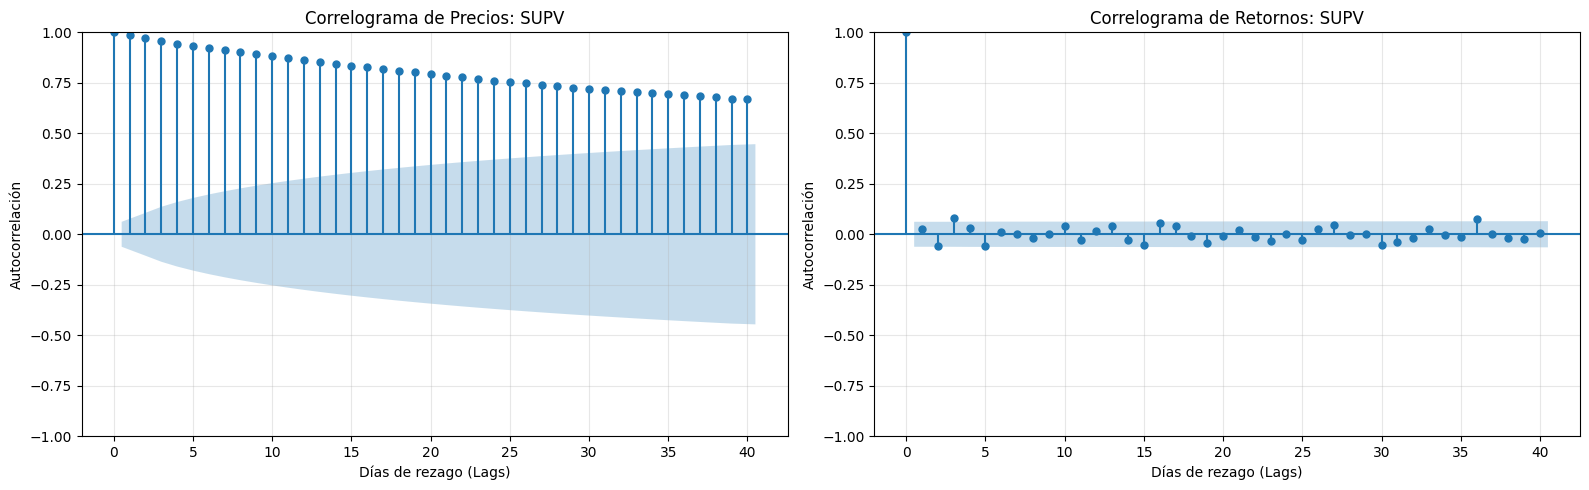

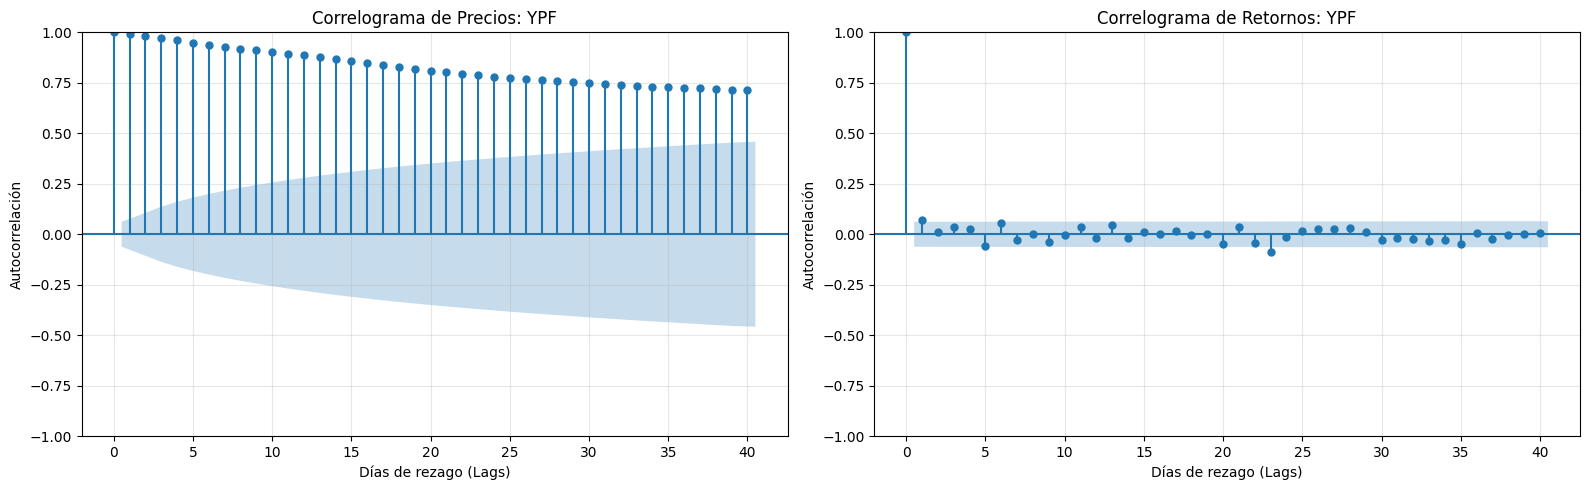

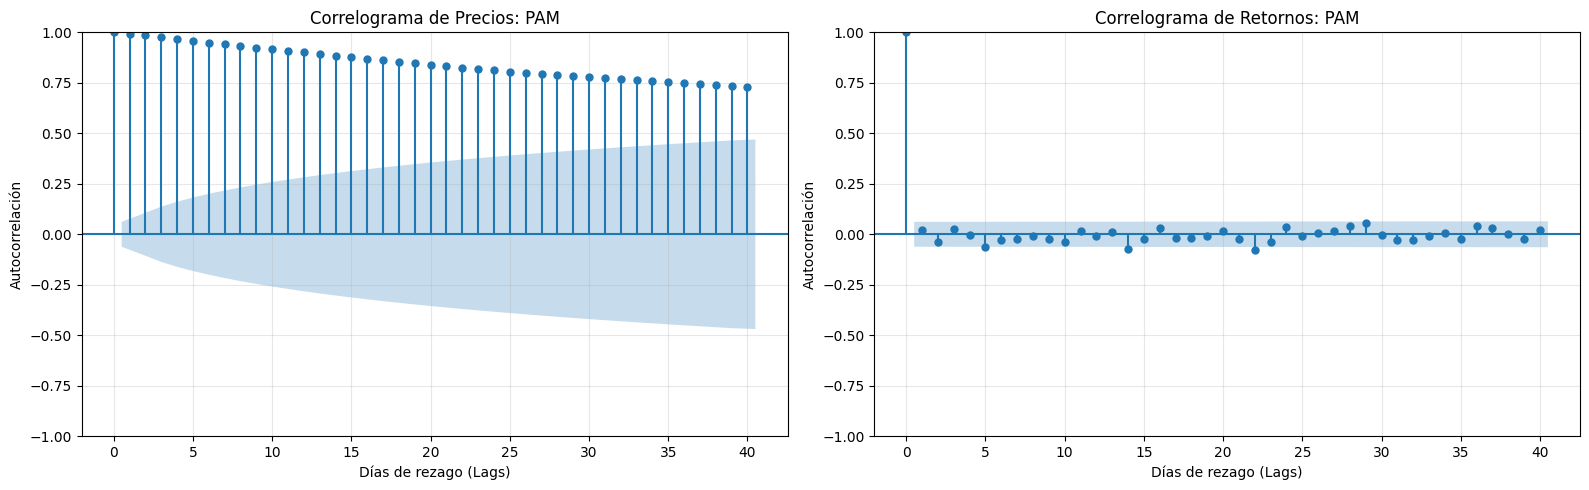

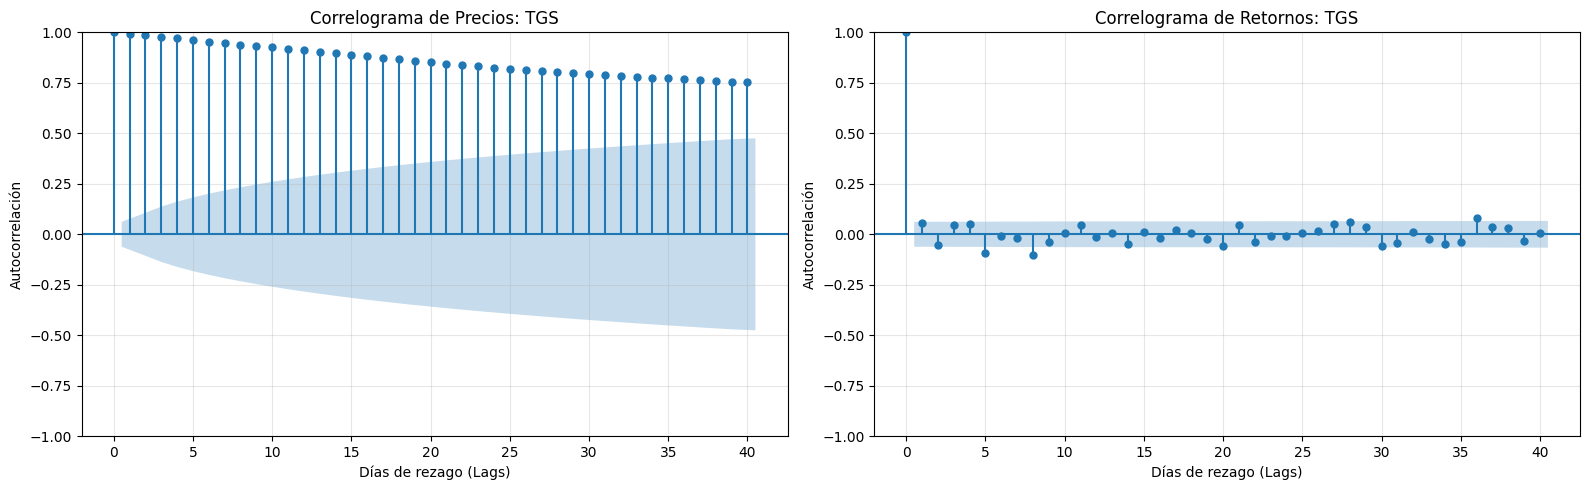

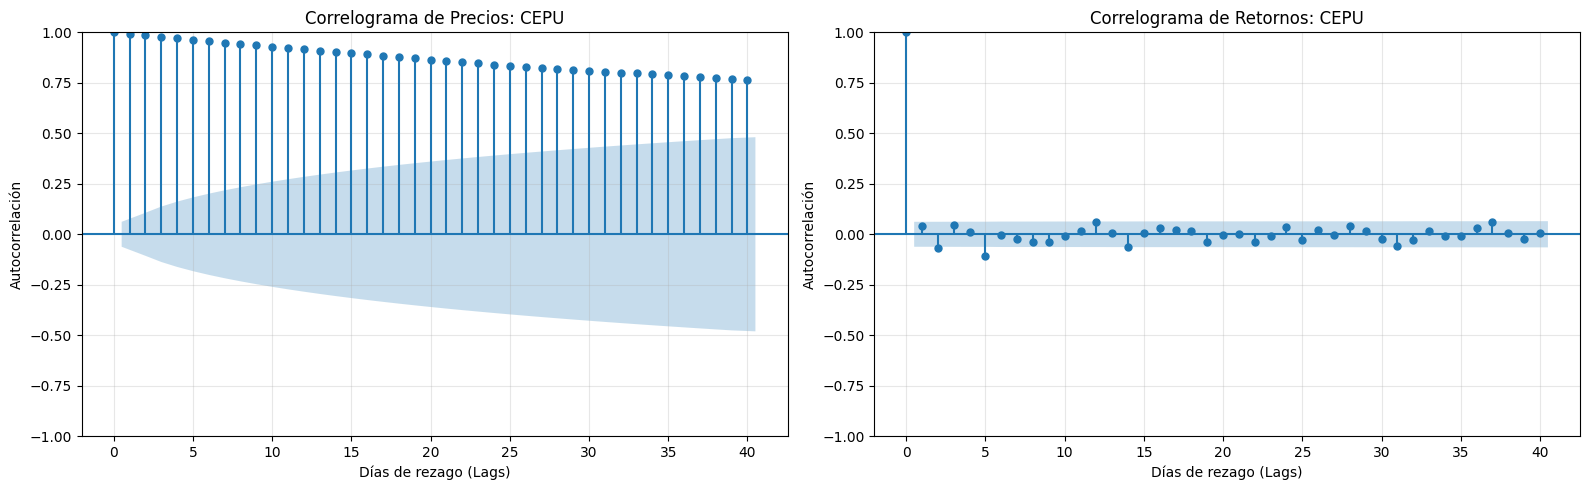

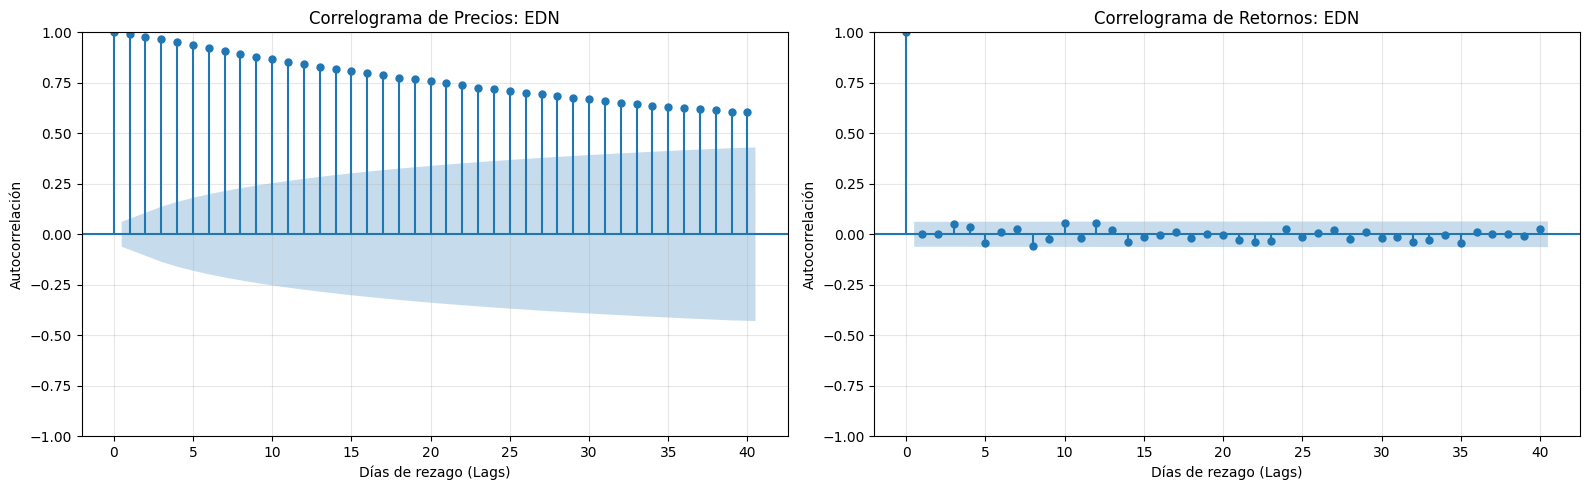

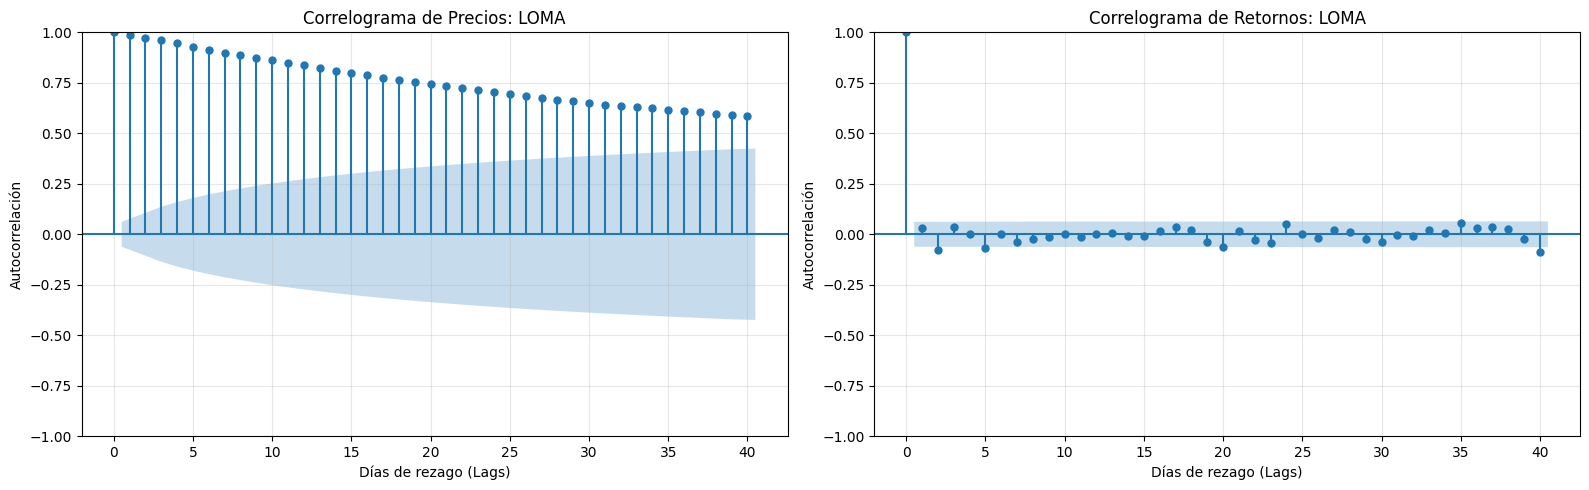

In [24]:

from statsmodels.graphics.tsaplots import plot_acf

# Obtenemos la lista de tickers desde las columnas del DataFrame
mis_tickers = precios_4y.columns

# Iteramos sobre cada activo
for ticker in mis_tickers:
    # Creamos una figura nueva para cada activo (una fila con 2 columnas)
    fig, ax = plt.subplots(1, 2, figsize=(16, 5))

    # --- GRÁFICO 1: Correlograma de PRECIOS (Izquierda) ---
    # Muestra la memoria de largo plazo (No estacionariedad)
    plot_acf(precios_4y[ticker], ax=ax[0], lags=40, title=f"Correlograma de Precios: {ticker}")
    ax[0].set_xlabel("Días de rezago (Lags)")
    ax[0].set_ylabel("Autocorrelación")
    ax[0].grid(True, alpha=0.3)

    # --- GRÁFICO 2: Correlograma de RETORNOS (Derecha) ---
    # Muestra la capacidad predictiva a corto plazo (Eficiencia)
    plot_acf(retornos_4y[ticker].dropna(), ax=ax[1], lags=40, title=f"Correlograma de Retornos: {ticker}")
    ax[1].set_xlabel("Días de rezago (Lags)")
    ax[1].set_ylabel("Autocorrelación")
    ax[1].grid(True, alpha=0.3)

    # Ajustamos el diseño y mostramos
    plt.tight_layout()
    plt.show()

Efectivamente, los retornos parecen impredecibles mientras que el precio de un activo en t parece ser un buen predictor del precio de ese activo en t+1. Pasemos a analizar correlaciones entre acciones para testear las estrategias de trading propuestas. Usaremos la biblioteca seaborn, construida sobre matplotlib, para graficar las correlaciones y ganar intuición visual.

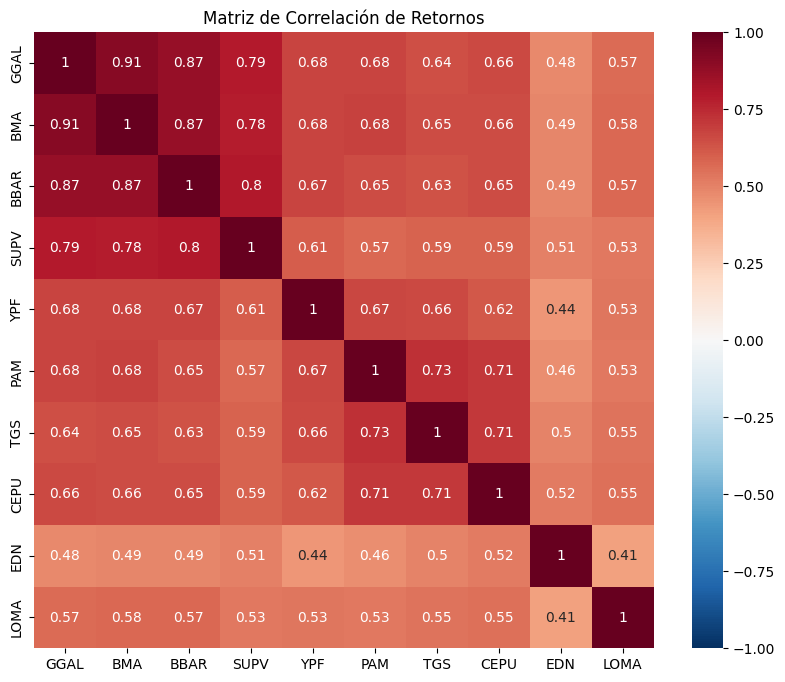

El par más correlacionado es: ('GGAL', 'BMA') con una correlación de 0.9093


In [25]:
import seaborn as sns
import numpy as np

# 1. Calculamos la matriz de correlación sobre tus datos existentes
matriz_corr = retornos_4y.corr()

# 2. Visualizamos con un Mapa de Calor
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr,
            annot=True,       # Muestra el valor en cada celda
            cmap='RdBu_r',    # Rojo para positivo, Azul para negativo
            vmin=-1, vmax=1)
plt.title("Matriz de Correlación de Retornos")
plt.show()

# 3. Identificamos el par con mayor correlación (excluyendo la diagonal)
# Creamos una máscara para borrar la diagonal (que siempre es 1)
mask = np.ones(matriz_corr.shape, dtype=bool)
np.fill_diagonal(mask, 0)
corr_sin_diag = matriz_corr.where(mask)

# Buscamos el máximo
max_corr = corr_sin_diag.max().max()
par_ganador = corr_sin_diag.stack().idxmax()

print(f"El par más correlacionado es: {par_ganador} con una correlación de {max_corr:.4f}")

Como era de esperar, los bancos tienen fuertísima correlación en retornos. Usaremos a Banco Galicia y Banco Macro (con correlación en retornos de 0.9093) para testear las estrategias de trading propuestas.

Queremos codear una estrategia en la que en ell día t se compra la acción si en el día t-1 el retorno fue negativo. La consigna sin duda está abierta a interpretación y esta es la manera en la que nosotros decidimos testear estas estrategias: supongamos que tenemos dos individuos y a cada uno le damos $100.000. El primer sigue la estrategia "comprar y mantener" (o buy and hold) y el segundo opera bajo el siguiente algoritmo. Si la acción considerada tuvo retorno negativo en t, el día t+1 invertirá el 10% de su dinero en efectivo en la acción. Esta regla sin duda es arbitraria pero nos parece razonable para que el individuo pueda "comprar las caídas" varias veces. Al definir todo esto en forma de función podemos jugar con los parámetros (porcentaje de comisión, capital inicial y fecha de inicio) para estudiar distintos escenarios.

/tmp/ipython-input-122459542.py:13: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  retornos_test = precios_test.pct_change()


--- GGAL ---
Final Buy & Hold: $89,715.00
Final Estrategia: $85,539.12
Diferencia: -4.65% vs B&H

--- BMA ---
Final Buy & Hold: $97,599.50
Final Estrategia: $93,655.74
Diferencia: -4.04% vs B&H



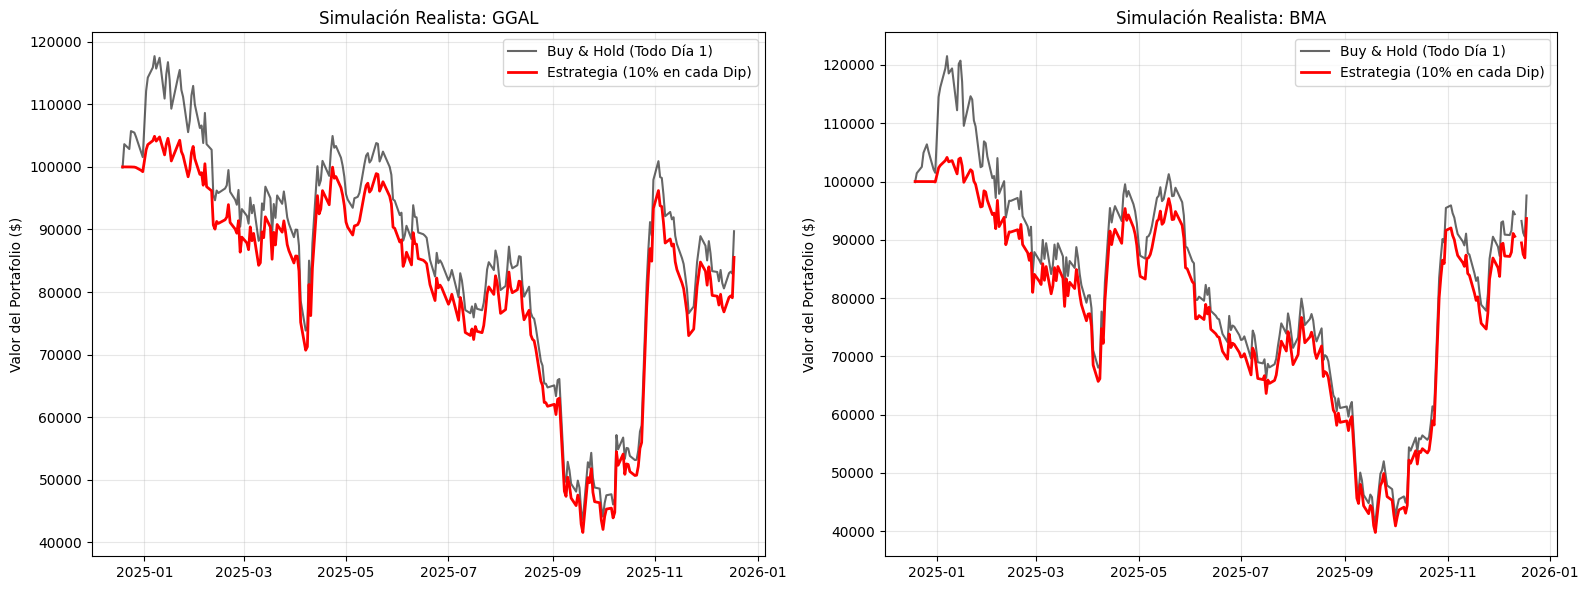

In [39]:

import numpy as np

# 1. PREPARACIÓN DE DATOS
# -----------------------
# Usamos el dataframe 'precios' que tiene los 5 años
fecha_inicio_test = "2024-12-19"
activos = ["GGAL", "BMA"]

# Recortamos los precios desde la fecha de inicio
precios_test = precios.loc[fecha_inicio_test:, activos].copy()

# Calculamos retornos diarios para saber si subió o bajó
retornos_test = precios_test.pct_change()

# 2. FUNCIÓN DE BACKTESTING (ACUMULACIÓN)
# ---------------------------------------
def simular_acumulacion(ticker, df_precios, df_retornos, capital_inicial=100000, comision=0.001):

    # --- A. "Estrategia buy and hold" ---
    # Compramos todo el día 1
    # Plata neta para acciones = Capital - 0.1% de comisión
    inversion_neta_bh = capital_inicial * (1 - comision)
    precio_inicial = df_precios[ticker].iloc[0]
    acciones_bh = inversion_neta_bh / precio_inicial

    # El valor diario es: Cantidad Acciones * Precio del Día
    equity_bh = acciones_bh * df_precios[ticker]

    # --- B. Estrategia "buy the dip"
    caja = capital_inicial
    acciones = 0
    historia_patrimonio = [] # Aquí guardaremos el valor total día a día

    # Recorremos día por día
    # Usamos enumerate para tener el índice numérico (i) y la fecha
    fechas = df_precios.index

    for i in range(len(fechas)):
        fecha_actual = fechas[i]
        precio_hoy = df_precios[ticker].iloc[i]

        # Saltamos el primer día porque no tiene "ayer"
        if i > 0:
            # Regla: ¿El retorno de AYER fue negativo?
            # Miramos el retorno en la posición i-1
            retorno_ayer = df_retornos[ticker].iloc[i-1]

            if retorno_ayer < 0 and caja > 10: # Si bajó y tengo algo de plata (> $10)
                # Compramos: 10% de la caja disponible
                monto_compra_bruto = caja * 0.10
                costo_comision = monto_compra_bruto * comision
                monto_neto = monto_compra_bruto - costo_comision

                # Compramos acciones
                nuevas_acciones = monto_neto / precio_hoy
                acciones += nuevas_acciones

                # Restamos de la caja lo que gastamos (bruto)
                caja -= monto_compra_bruto

        # Calculamos cuánto tengo hoy: Efectivo Sobrante + Valor de mis Acciones
        patrimonio_total = caja + (acciones * precio_hoy)
        historia_patrimonio.append(patrimonio_total)

    # Convertimos la lista en una Serie de Pandas para graficar
    equity_estrategia = pd.Series(historia_patrimonio, index=fechas)

    return equity_bh, equity_estrategia

# 3. EJECUCIÓN Y GRÁFICOS
# -----------------------
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

for i, ticker in enumerate(activos):
    # Corremos la simulación
    curva_bh, curva_estrat = simular_acumulacion(ticker, precios_test, retornos_test)

    # Graficamos
    ax[i].plot(curva_bh, label="Buy & Hold (Todo Día 1)", color="black", alpha=0.6)
    ax[i].plot(curva_estrat, label="Estrategia (10% en cada Dip)", color="red", linewidth=2)

    ax[i].set_title(f"Simulación Realista: {ticker}")
    ax[i].set_ylabel("Valor del Portafolio ($)")
    ax[i].legend()
    ax[i].grid(True, alpha=0.3)

    # Resultados Finales
    res_bh = curva_bh.iloc[-1]
    res_estrat = curva_estrat.iloc[-1]

    print(f"--- {ticker} ---")
    print(f"Final Buy & Hold: ${res_bh:,.2f}")
    print(f"Final Estrategia: ${res_estrat:,.2f}")
    print(f"Diferencia: {((res_estrat/res_bh)-1)*100:.2f}% vs B&H\n")

plt.tight_layout()
plt.show()

Jugando con los parámetros vemos que consistentemente la estrategia buy and hold gana, para ambos activos, aún cuando las comisiones son nulas. Es evidencia a favor de la hipótesis de los mercados eficientes: no se puede explotar la información en precios o retornos para deiseñar estrategias con las que ganar dinero. Lo más interesante aún es que para varios escenarios, en particular en el último año, con no hacer absolutamente nada (ni siquiera un plazo fijo) se obtenía más dinero que invirtiendo en acciones: hay varias parametrizaciones para los cuales el valor final de las inversiones es menor al capital inicial